# High school the Hypergraph

[Source](https://www.cs.cornell.edu/~arb/data/contact-high-school/)


In [1]:
# Load the contact-high-school temporal hypergraph dataset
using DelimitedFiles

# Load the three data files
nverts_file = "contact-high-school/contact-high-school-nverts.txt"
simplices_file = "contact-high-school/contact-high-school-simplices.txt"  
times_file = "contact-high-school/contact-high-school-times.txt"

# Read number of vertices per simplex
nverts_full = vec(readdlm(nverts_file, Int))
println("Total number of simplices: ", length(nverts_full))

# Read all simplex node IDs (contiguous list)
all_nodes_full = vec(readdlm(simplices_file, Int))
println("Total node entries: ", length(all_nodes_full))

# Read timestamps
timestamps_full = vec(readdlm(times_file, Int))
println("Total timestamps: ", length(timestamps_full))

# Filter to first 80 nodes only
all_unique_nodes = sort(unique(all_nodes_full))
first_80_nodes = Set(all_unique_nodes[1:80])
println("Filtering to first 80 nodes: $(minimum(all_unique_nodes[1:80])) to $(maximum(all_unique_nodes[1:80]))")

# Filter simplices to only include those with all nodes in first 80
filtered_indices = Int[]
node_idx = 1

for (simplex_idx, nvert) in enumerate(nverts_full)
    # Extract nodes for this simplex
    simplex_nodes = all_nodes_full[node_idx:(node_idx + nvert - 1)]
    
    # Check if all nodes are in first 80
    if all(node in first_80_nodes for node in simplex_nodes)
        push!(filtered_indices, simplex_idx)
    end
    
    node_idx += nvert
end

# Create filtered datasets
nverts = nverts_full[filtered_indices]
timestamps = timestamps_full[filtered_indices]

# Rebuild all_nodes for filtered simplices
all_nodes = Int[]
node_idx = 1
for simplex_idx in filtered_indices
    nvert = nverts_full[simplex_idx]
    # Find the original position of this simplex
    orig_pos = sum(nverts_full[1:simplex_idx-1]) + 1
    simplex_nodes = all_nodes_full[orig_pos:(orig_pos + nvert - 1)]
    append!(all_nodes, simplex_nodes)
end

println("\nFiltered dataset statistics:")
println("Number of timestamped simplices: ", length(nverts))
println("Number of unique node IDs: ", length(unique(all_nodes)))
println("Simplex size distribution:")

# Count simplex sizes manually
size_counts = Dict{Int, Int}()
for size in nverts
    size_counts[size] = get(size_counts, size, 0) + 1
end

for size in sort(collect(keys(size_counts)))
    count = size_counts[size]
    println("  Size $size: $count simplices")
end

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to first 80 nodes: 1 to 80

Filtered dataset statistics:
Number of timestamped simplices: 30077
Number of unique node IDs: 80
Simplex size distribution:
  Size 2: 29640 simplices
  Size 3: 428 simplices
  Size 4: 9 simplices


In [2]:
# Parse simplices from the contiguous node list
simplices = Vector{Vector{Int}}()
node_idx = 1

for nvert in nverts
    # Extract nodes for this simplex
    simplex_nodes = all_nodes[node_idx:(node_idx + nvert - 1)]
    push!(simplices, simplex_nodes)
    node_idx += nvert
end

println("Parsed ", length(simplices), " simplices")
println("First few simplices:")
for i in 1:min(10, length(simplices))
    println("  Simplex $i (time $(timestamps[i])): $(simplices[i])")
end

Parsed 30077 simplices
First few simplices:
  Simplex 1 (time 1385982020): [2, 1]
  Simplex 2 (time 1385982020): [9, 11]
  Simplex 3 (time 1385982020): [40, 39]
  Simplex 4 (time 1385982020): [46, 45]
  Simplex 5 (time 1385982020): [26, 25]
  Simplex 6 (time 1385982020): [55, 56]
  Simplex 7 (time 1385982020): [42, 41]
  Simplex 8 (time 1385982020): [29, 28]
  Simplex 9 (time 1385982020): [58, 57]
  Simplex 10 (time 1385982020): [60, 59]


In [3]:
# Create simple temporal simplex structure for processing
temporal_simplices = [(simplices[i], timestamps[i], nverts[i]) for i in 1:length(simplices)]

println("Created temporal hypergraph with ", length(temporal_simplices), " temporal simplices")

# Basic statistics
all_unique_nodes = sort(unique(all_nodes))
println("Number of nodes: ", length(all_unique_nodes))
println("Time range: $(minimum(timestamps)) to $(maximum(timestamps))")

println("\nReady for tensor creation!")

Created temporal hypergraph with 30077 temporal simplices
Number of nodes: 80
Time range: 1385982020 to 1386345520

Ready for tensor creation!


In [4]:
# Summary: Data loaded and ready for tensor creation
println("✅ Data loading complete!")
println("- $(length(temporal_simplices)) temporal simplices loaded")  
println("- $(length(all_unique_nodes)) unique nodes (students)")
println("- Time range: $(minimum(timestamps)) to $(maximum(timestamps))")
println("- Ready for 3-mode tensor creation and chiseling analysis")

✅ Data loading complete!
- 30077 temporal simplices loaded
- 80 unique nodes (students)
- Time range: 1385982020 to 1386345520
- Ready for 3-mode tensor creation and chiseling analysis


In [5]:
# Load Dleto for chiselling analysis (following WhatWeEatInAmerica pattern)
using Pkg
Pkg.activate("../")  # Activate the main project
using Dleto
using ITensors  # Need this for Index, ITensor, etc.
using Statistics
using Plots

  Activating project at `~/CODE/OpenDleto`


WebIO._IJuliaInit()

Loading Dleto Plots Extension


In [6]:
# Create a 3-mode tensor by decomposing hyperedges into 3-node subsets
# Using only the first 80 nodes for efficiency

println("Creating 3-mode tensor from hyperedge decomposition (first 80 nodes only)...")

# Get unique nodes and limit to first 80
all_unique_nodes = sort(unique(all_nodes))
unique_nodes = all_unique_nodes[1:80]  # Only use first 80 nodes
node_to_idx = Dict(node => i for (i, node) in enumerate(unique_nodes))
n_nodes = 80

# For a 3-mode tensor, each mode represents one node position in a triangle
# We'll count occurrences of 3-node combinations from the hypergraph

println("Tensor dimensions:")
println("  Node 1: $n_nodes")
println("  Node 2: $n_nodes") 
println("  Node 3: $n_nodes")
println("  Total entries: $(n_nodes^3)")
println("  Using nodes: $(minimum(unique_nodes)) to $(maximum(unique_nodes))")

# Function to generate all 3-node combinations from a hyperedge (simple implementation)
function get_3node_combinations(nodes)
    if length(nodes) < 3
        return []
    elseif length(nodes) == 3
        return [nodes]
    else
        # Generate all combinations of 3 nodes manually
        combinations = []
        for i in 1:length(nodes)-2
            for j in i+1:length(nodes)-1
                for k in j+1:length(nodes)
                    push!(combinations, [nodes[i], nodes[j], nodes[k]])
                end
            end
        end
        return combinations
    end
end

Creating 3-mode tensor from hyperedge decomposition (first 80 nodes only)...
Tensor dimensions:
  Node 1: 80
  Node 2: 80
  Node 3: 80
  Total entries: 512000
  Using nodes: 1 to 80


get_3node_combinations (generic function with 1 method)

In [7]:
# Create ITensor indices for the 3-mode tensor
using ITensors
i = Index(n_nodes, "node1")  # First node in triangle
j = Index(n_nodes, "node2")  # Second node in triangle  
k = Index(n_nodes, "node3")  # Third node in triangle

# Create the 3-node combination tensor
Triangles = ITensor(Float32,i, j, k)

# Populate the tensor by counting 3-node combinations
processed_simplices = 0
total_triangles = 0
skipped_small = 0

for (idx, ts) in enumerate(temporal_simplices)
    # Get all 3-node combinations from this hyperedge
    triangle_combinations = get_3node_combinations(ts[1])  # ts[1] is the nodes vector
    
    if isempty(triangle_combinations)
        skipped_small += 1
        continue
    end
    
    # Add each triangle to the tensor (only if all nodes are in first 80)
    for triangle in triangle_combinations
        # Convert nodes to indices, filter to only include first 80 nodes
        node_indices = []
        for node in triangle
            if node in keys(node_to_idx)  # Only nodes in first 80
                push!(node_indices, node_to_idx[node])
            end
        end
        
        if length(node_indices) == 3  # All 3 nodes are in our subset
            a, b, c = node_indices[1], node_indices[2], node_indices[3]
            
            # Add to all permutations to make tensor symmetric
            # All 6 permutations of (a,b,c)
            Triangles[i=>a, j=>b, k=>c] += 1.0
            Triangles[i=>a, j=>c, k=>b] += 1.0
            Triangles[i=>b, j=>a, k=>c] += 1.0
            Triangles[i=>b, j=>c, k=>a] += 1.0
            Triangles[i=>c, j=>a, k=>b] += 1.0
            Triangles[i=>c, j=>b, k=>a] += 1.0
            
            total_triangles += 1
        end
    end
    
    processed_simplices += 1
end

# Analyze the tensor
T_array = Array(Triangles, i, j, k)
non_zero_entries = count(x -> x != 0, T_array)
total_entries = length(T_array)

println("✅ 3-mode triangle tensor created!")
println("Processed simplices: $processed_simplices")
println("Skipped simplices (< 3 nodes): $skipped_small")
println("Total triangles extracted: $total_triangles")
println("Non-zero tensor entries: $non_zero_entries / $total_entries")
println("Sparsity: $(round((total_entries - non_zero_entries) / total_entries * 100, digits=1))%")
println("Max triangle count: $(Int(maximum(T_array)))")
println("Mean triangle count: $(round(mean(T_array[T_array .> 0]), digits=2))")

✅ 3-mode triangle tensor created!
Processed simplices: 437
Skipped simplices (< 3 nodes): 29640
Total triangles extracted: 464
Non-zero tensor entries: 588 / 512000
Sparsity: 99.9%
Max triangle count: 54
Mean triangle count: 4.73


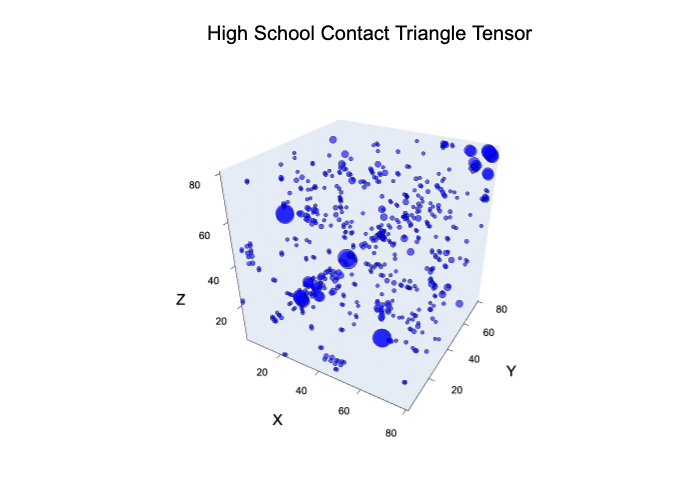

In [8]:
# Plot the tensor using Dleto's plotting function
plot_tensor(Triangles, title="High School Contact Triangle Tensor")

In [ ]:
# Create a 80x80x80 subsample tensor for faster processing
println("Creating 80×80×80 subsample tensor...")

max = 80
# Create smaller indices for the subsample
i_small = Index(max, "node1_small")
j_small = Index(max, "node2_small") 
k_small = Index(max, "node3_small")

# Create the subsample tensor
SmallHigh = ITensor(i_small, j_small, k_small)

# Extract the first 80×80×80 portion from the full tensor
T_array = Array(Triangles, i, j, k)
T_small_array = T_array[1:max, 1:max, 1:max]

# Populate the SmallHigh tensor
for a in 1:max, b in 1:max, c in 1:max
    if T_small_array[a, b, c] != 0
        SmallHigh[i_small=>a, j_small=>b, k_small=>c] = T_small_array[a, b, c]
    end
end

# Analyze the subsample
small_non_zero = count(x -> x != 0, T_small_array)
small_total = length(T_small_array)

println("✅ Subsample tensor created!")

# Perform stratified decomposition on the subsample
println("\n🔬 Performing stratified decomposition on SmallHigh tensor...")
@time SmallHigh_strat, Xs_strat_small = stratify(SmallHigh);

println("✅ SmallHigh stratification complete!")


Creating 80×80×80 subsample tensor...
✅ Subsample tensor created!


┌ Warning: More than 1,000 viewable entries, plotting only the largest points.
└ @ DletoPlotsExt ~/CODE/OpenDleto/ext/DletoPlotsExt.jl:257


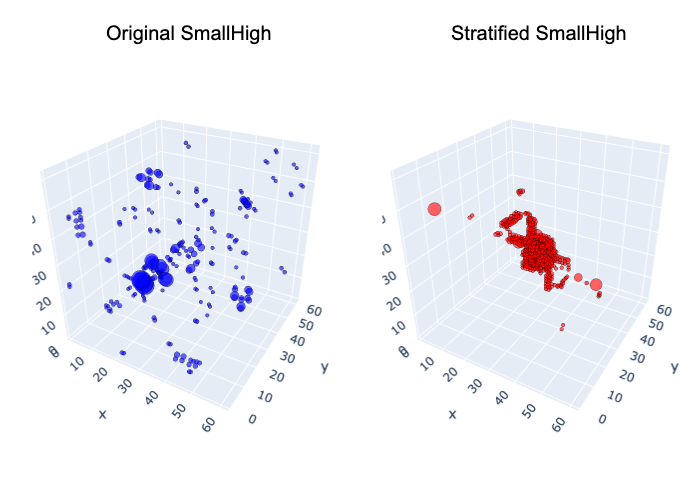

In [16]:
# Plot SmallHigh and SmallHigh_strat side by side
p1 = plot_tensor(SmallHigh; title="Original SmallHigh", color=:blue)
p2 = plot_tensor(SmallHigh_strat; title="Stratified SmallHigh", color=:red)
Plots.plot(p1, p2; layout=(1,2), size=(800,400))

In [ ]:
# Analyze the stratified results - Node position patterns (SmallHigh subsample)
# Following WhatWeEatInAmerica pattern for coordinate analysis

println("\n🎯 Analyzing node position patterns in SmallHigh triangles...")

# Analyze the first node position (i_small index)
node1_1 = ITensor(i_small); node1_1[i_small=>1] = 1.0;

# Find which transverse operator corresponds to the first node position
node1_operator_idx = 0
for (idx, X) in enumerate(Xs_strat_small)
    if i_small in inds(X)
        node1_operator_idx = idx
        break
    end
end

if node1_operator_idx > 0
    # Compute the stratified representation of the first node in first position
    mix_node1_1 = Xs_strat_small[node1_operator_idx] * node1_1
    mix_node1_1_array = Array(mix_node1_1, inds(mix_node1_1))
    
    println("Node 1 in first position - stratified representation:")
    for (idx, weight) in enumerate(mix_node1_1_array)
        if abs(weight) > 1e-6
            println("  $(round(weight*100, digits=1))% × stratified coordinate $idx")
        end
    end
else
    println("Could not find first node position operator in stratification")
end

In [ ]:
# Analyze second and third node position patterns (SmallHigh subsample)
println("\n🔄 Analyzing second and third node positions...")

# Analyze the second node position (j_small index)
node2_1 = ITensor(j_small); node2_1[j_small=>1] = 1.0;
node2_operator_idx = 0
for (idx, X) in enumerate(Xs_strat_small)
    if j_small in inds(X)
        node2_operator_idx = idx
        break
    end
end

if node2_operator_idx > 0
    mix_node2_1 = Xs_strat_small[node2_operator_idx] * node2_1
    mix_node2_1_array = Array(mix_node2_1, inds(mix_node2_1))
    
    println("Node 1 in second position - stratified representation:")
    for (idx, weight) in enumerate(mix_node2_1_array)
        if abs(weight) > 1e-6
            println("  $(round(weight*100, digits=1))% × stratified coordinate $idx")
        end
    end
end

# Analyze the third node position (k_small index)  
node3_1 = ITensor(k_small); node3_1[k_small=>1] = 1.0;
node3_operator_idx = 0
for (idx, X) in enumerate(Xs_strat_small)
    if k_small in inds(X)
        node3_operator_idx = idx
        break
    end
end

if node3_operator_idx > 0
    mix_node3_1 = Xs_strat_small[node3_operator_idx] * node3_1
    mix_node3_1_array = Array(mix_node3_1, inds(mix_node3_1))
    
    println("\nNode 1 in third position - stratified representation:")
    for (idx, weight) in enumerate(mix_node3_1_array)
        if abs(weight) > 1e-6
            println("  $(round(weight*100, digits=1))% × stratified coordinate $idx")
        end
    end
end

println("\n✅ SmallHigh 3-mode hypergraph tensor analysis complete!")
println("Data structures available:")
println("- Triangles: Full 3-mode tensor of triangle counts")
println("- SmallHigh: 80×80×80 subsample tensor")
println("- SmallHigh_strat: Stratified subsample tensor")
println("- Xs_strat_small: Transverse operators for SmallHigh")
println("- temporal_simplices: Original temporal hypergraph data (tuples)")